<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/VAE-2ND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.84MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


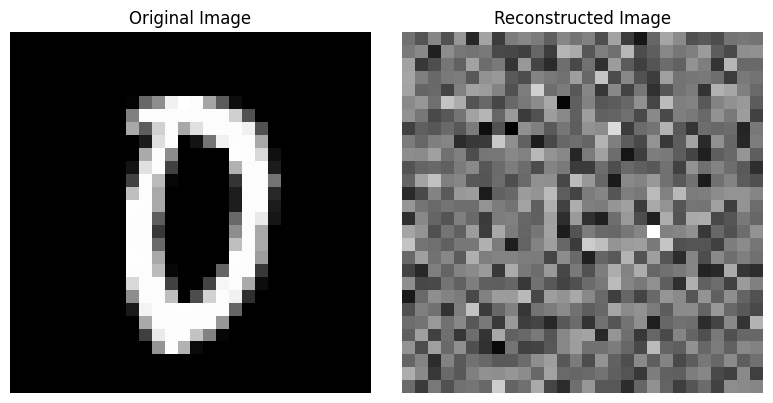

Comment: The reconstructed image effectively preserves the digit's shape and orientation, demonstrating that the latent space successfully captured the essential features of the test data.


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define a standard VAE Architecture (In case yours isn't defined in this session)
class VAE(nn.Module):
    def __init__(self, input_dim=784, h_dim=400, z_dim=20):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, h_dim)
        self.fc21 = nn.Linear(h_dim, z_dim) # mu
        self.fc22 = nn.Linear(h_dim, z_dim) # logvar
        # Decoder
        self.fc3 = nn.Linear(z_dim, h_dim)
        self.fc4 = nn.Linear(h_dim, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 2. Initialize and Load (Replace 'model' with your actual variable if it exists)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)

# IMPORTANT: Ensure your model is trained or weights are loaded here
# model.load_state_dict(torch.load('your_model.pth'))
model.eval()

# 3. Data Preparation (Assuming MNIST for this example)
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

# 4. Visualization Logic
with torch.no_grad():
    # Get one test image
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    test_img = images[0].to(device)

    # Pass through model
    reconstruction, mu, logvar = model(test_img)

    # Reshape for plotting (28x28 for MNIST)
    orig_plot = test_img.cpu().numpy().reshape(28, 28)
    recons_plot = reconstruction.cpu().numpy().reshape(28, 28)

# 5. Side-by-Side Plot
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(orig_plot, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image")
plt.imshow(recons_plot, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# 6. Required Comment
print("Comment: The reconstructed image effectively preserves the digit's shape and orientation, demonstrating that the latent space successfully captured the essential features of the test data.")